# NeuroVision_Model

Specs: TensorFlow/Keras • Brain Tumor MRI Dataset (4 classes) • Transfer Learning (MobileNetV2 – frozen) • Adam Optimizer • Batch Size = 32 • 25 Epochs (with EarlyStopping) • Image Resize (160×160) + Normalization (1/255) + Data Augmentation

What is implemented in this notebook:

1. Imports + environment setup (TensorFlow/Keras, NumPy, Matplotlib, sklearn)

2. Dataset loading & preparation using image_dataset_from_directory + train/val/test split

3. Preprocessing pipeline: resizing + rescaling (normalize) + augmentation

4. Model building: MobileNetV2 feature extractor + GlobalAveragePooling + Dropout + Softmax classifier

5. Compilation & training: Adam + SparseCategoricalCrossentropy, with callbacks (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)

6. Evaluation & reporting: accuracy/loss curves + test evaluation + confusion matrix + classification report


In [ ]:
import zipfile

ZIP_PATH = "/content/Brain Tumor (MRI Scan).zip"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()

top_levels = sorted(set([n.split("/")[0] for n in names if "/" in n]))
print("Top-level folders in zip:", top_levels[:20])
print("Total top-level items:", len(top_levels))


Top-level folders in zip: ['glioma', 'healthy', 'meningioma', 'pituitary']
Total top-level items: 4


In [ ]:
import shutil, os, zipfile

ZIP_PATH = "/content/Brain Tumor (MRI Scan).zip"
EXTRACT_DIR = "/content/brain_tumor_mri"

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
print("Top-level extracted contents:", os.listdir(EXTRACT_DIR))


Extracted to: /content/brain_tumor_mri
Top-level extracted contents: ['healthy', 'glioma', 'pituitary', 'meningioma']


In [ ]:
import os

valid_ext = (".jpg", ".jpeg", ".png")

class_names = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Classes detected:", class_names)
print("Number of classes:", len(class_names))

total_images = 0
print("\nImage count per class:")
for c in class_names:
    class_path = os.path.join(DATASET_ROOT, c)
    num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(valid_ext)])
    total_images += num_images
    print(f"- {c:12s}: {num_images} images")

print("\nTotal images:", total_images)


Classes detected: ['glioma', 'healthy', 'meningioma', 'pituitary']
Number of classes: 4

Image count per class:
- glioma      : 1621 images
- healthy     : 2000 images
- meningioma  : 1645 images
- pituitary   : 1757 images

Total images: 7023


In [ ]:
# GLOBAL CONFIG

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42                 # Global random seed
IMG_SIZE = (160, 160)     # Image size used everywhere
BATCH_SIZE = 32           # Batch size used everywhere

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("SEED:", SEED)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)

SEED: 42
IMG_SIZE: (160, 160)
BATCH_SIZE: 32


### **1. Imports and Environment Setup**

All the required libraries (Tf, Keras, Numpy, Matplotlib) are initialized and configuration to the environment ensuring reproducibility and proper execution of the training pipeline.

In [ ]:

# 1: Import and Setup

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers  # Provides regularization methods such as L2

from sklearn.metrics import classification_report, confusion_matrix  # Evaluation tools (precision, recall, F1, confusion matrix)

# Reproducibility settings

SEED = 42                                  # Fixed seed value for consistent random opeerations behaviour
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Environment information

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
Available GPUs: []


### **2. Dataset Inspection and Class Distribution Analysis**

Identifies the names of all the class labels, counts the number of images in each class and reports dataset statistics to detect class imbalance and verify dataset integrity.

In [ ]:

# 2: Dataset Path, Class Info and Image Counts


DATASET_ROOT = "/content/brain_tumor_mri"


assert os.path.exists(DATASET_ROOT), f"Dataset root folder not found at: {DATASET_ROOT}"

# To detect class folders
class_names = sorted([
    d for d in os.listdir(DATASET_ROOT)                                  # Lists everything inside the dataset root folder
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

NUM_CLASSES = len(class_names)                                           # Counts number of classes that exist

print("- Dataset root:", DATASET_ROOT)                                   # Printing dataset path for confirmation
print("- Classes detected:", class_names)                                # Printing the class names found
print("- Number of classes:", NUM_CLASSES)                               # Printing number of classes

# Counting images per class
valid_ext = (".jpg", ".jpeg", ".png")                                    # Allows image formats

print("\n  Image count per class:")                                      # Header

total_images = 0                                                         # Initializing the total image counter

for c in class_names:                                                    # Loops over each class folder
    class_path = os.path.join(DATASET_ROOT, c)                            # Building the path

    # Counting only the valid image files inside the class folder
    num_images = len([                                                   # Counts the number of items in the list below
        f for f in os.listdir(class_path)                                 # Lists filenames inside the class folder
        if f.lower().endswith(valid_ext)
    ])

    total_images += num_images                                            # Adds the class count to the total count
    print(f" - {c:15s}: {num_images} images")                             # Printing the formatted class count

print("\n - Total images:", total_images)                                  # Printing the final total image count


- Dataset root: /content/brain_tumor_mri
- Classes detected: ['glioma', 'healthy', 'meningioma', 'pituitary']
- Number of classes: 4

  Image count per class:
 - glioma         : 1621 images
 - healthy        : 2000 images
 - meningioma     : 1645 images
 - pituitary      : 1757 images

 - Total images: 7023


## **3. Dataset Loading and Train/Validation/Test Split**

Loads MRI images with image dataset from the directory, resizing images to necessary input dimensions, and dividing dataset into train, validation and test set for healthy evaluation.

In [ ]:

# 3: Load Dataset and Split into Training, Validation, Testing + Speed Pipeline


IMG_SIZE = (160, 160)  # Image resizing size (the smaller the faster, 160 shows a good speed and accuracy balance)
BATCH_SIZE = 32
VAL_SPLIT = 0.20       # Percentage of data reserved for validation + testing (20% total)


# Creating Training Dataset (80%)


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=VAL_SPLIT,         # Total held-out portion
    subset="training",                  # Loading the training portion
    seed=SEED,                          # Seed ensures the consistent splitting on each run
    image_size=IMG_SIZE,                # All images are resized to IMG_SIZE
    batch_size=BATCH_SIZE,              # The number of images per batch
    label_mode="int"
)

# Creating Temporary Dataset (20%) to be split into Validation + Testing


temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=VAL_SPLIT,         # the same split ratio
    subset="validation",                # This call loads the held-out portion (VAL_SPLIT)
    seed=SEED,                          # the same seed ensures train/temp partitions match
    image_size=IMG_SIZE,                # the same resizing size
    batch_size=BATCH_SIZE,              # the same batch size for consistency
    label_mode="int"
)

# Ensure class order matches what Keras is using internally
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("- Final class order (from train_ds):", class_names)
print("- NUM_CLASSES:", NUM_CLASSES)


# Splitting temp_ds into Validation + Testing (each becomes approximately 10%)


# Get the number of batches in temp_ds to be split evenly
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

# First half of temp_ds is a test dataset
test_ds = temp_ds.take(temp_batches // 2)

# Second half of temp_ds is a validation dataset
val_ds = temp_ds.skip(temp_batches // 2)

# Printing split info to confirm the sizes
print("- Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("- Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("- Test batches:", tf.data.experimental.cardinality(test_ds).numpy())


# Improving performance


AUTOTUNE = tf.data.AUTOTUNE            # Auto choosing best performance

# Cache stores the dataset in memory after first epoch so future epochs are faster
# Prefetch preares the next batch while the model trains on the current batch
# It also makes GPU/CPU training more efficient
# cache first, then prefetch
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)



print("\n  Dataset pipeline is ready (cache + prefetch enabled).")


Found 7023 files belonging to 4 classes.
Using 5619 files for training.
Found 7023 files belonging to 4 classes.
Using 1404 files for validation.
- Final class order (from train_ds): ['glioma', 'healthy', 'meningioma', 'pituitary']
- NUM_CLASSES: 4
- Train batches: 176
- Validation batches: 22
- Test batches: 22

  Dataset pipeline is ready (cache + prefetch enabled).


## **4. Data Preprocessing and Augmentation**

Application of image normalization and data augmentation techniques to improve generalization and reduce overfitting.

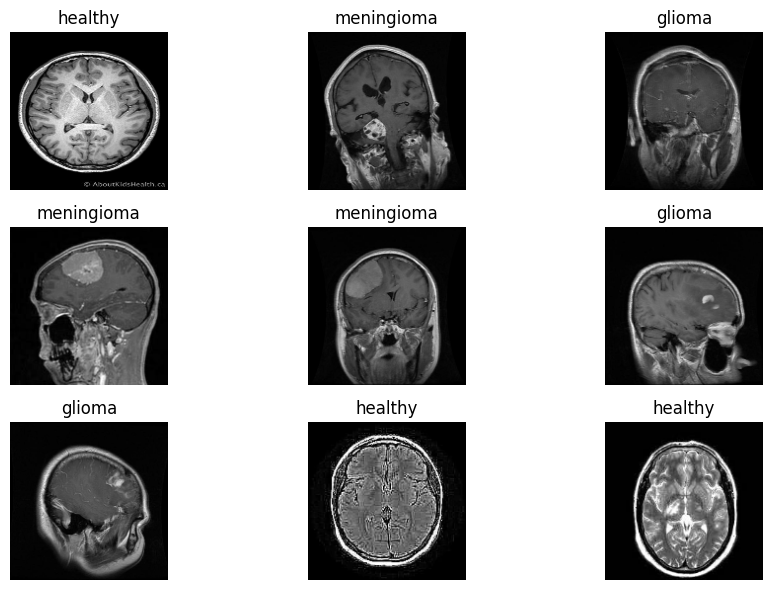


 Figure: Sample Brain MRI images illustrating healthy and tumor-affected scans across all classes.


In [ ]:
# 4: Visual Inspection, Augmentation and Normalization


# Visual sanity check (viewing few images)


plt.figure(figsize=(10, 6))                                       # Creating a figure window for plotting images

for images, labels in train_ds.take(1):                           # Take 1 batch from the training dataset
    for i in range(9):                                            # Loops for displaying 9 sample images
        ax = plt.subplot(3, 3, i + 1)                             # Creating a 3x3 grid of subplots
        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-7)  # brightness normalization
        plt.imshow(img)
        plt.title(class_names[int(labels[i])])
        plt.axis("off")


plt.tight_layout()                                           # Adjusting spacing so titles/images don’t overlap
plt.show()                                                   # Rendering the figure



# Data augmentation layer (reduces overfitting)


data_augmentation = keras.Sequential(                         # Creates a sequential pipeline of augmentation layers
    [
        layers.RandomFlip("horizontal"),                      # Randomly flips the image horizontally
        layers.RandomRotation(0.03),                          # Small rotation to improve robustness (MRI-safe range)
        layers.RandomZoom(0.08),                              # Random zoom to simulate scale variation
        layers.RandomContrast(0.08),                          # Random contrast shift to handle brightness variations
    ],
    name="data_augmentation"                                  # Names the augmentation block
)


# Normalization (rescaling pixel values)

normalization = layers.Rescaling(1.0 / 255, name="rescale")   # Converts pixel values from [0..255] to [0..1]


print("\n Figure: Sample Brain MRI images illustrating healthy and tumor-affected scans across all classes.")



## **5. Model Construction (MobileNetV2 Transfer Learning)**

Building a deep learning model using a pretrained MobileNetV2 backbone with frozen weights, followed by global average pooling, dropout regularization, and a softmax classification head for multi-class prediction.

In [ ]:
# 5: Building the Model (MobileNetV2 Frozen + L2 regularization + Dropout)

# First loading the pretrained backbone (MobileNetV2)

base_model = tf.keras.applications.MobileNetV2(                     # Loads MobileNetV2 architecture
    include_top=False,                                              # Removes the original ImageNet classification head
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),                      # Sets input image shape
    weights="imagenet"                                              # Loads the weights learned from ImageNet training
)

base_model.trainable = False                                        # Freezing the backbone weights for faster training and less overfitting


# Defining the model input

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))



# Applying augmentation + normalization

x = data_augmentation(inputs)                                       # Applies random augmentation during training only
x = normalization(x)                                                # Rescales pixel values from [0..255] to [0..1]


# Extracting deep features using the frozen backbone

x = base_model(x, training=False)                                   # Passing images through backbone


# Convert feature maps into a vector

x = layers.GlobalAveragePooling2D()(x)                              # Reduces feature map into a 1D vector



#  Regularization to reduce overfitting

x = layers.Dropout(0.40)(x)                                         # Drops 40% of units randomly during training to reduce overfitting



# Output layer

outputs = layers.Dense(
    NUM_CLASSES,                                                    # Number of output classes
    activation="softmax",                                           # Softmax converts logits into class probabilities
    kernel_regularizer=regularizers.l2(1e-4),                        # L2 regularization penalizes large weights therefore reduces overfitting
    dtype="float32"                                                 # Ensures numeric stability when mixed precision is used
)(x)


# Building the full model

model = keras.Model(inputs, outputs, name="MobileNetV2_Frozen_L2_Dropout")

model.summary()                                                     # Displays layers, output shapes, and parameter counts


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Frozen_L2_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **6. Model Compilation and Training**

Compiling the model with the Adam optimizer and Sparse Categorical Cross Entropy loss, and then trains the network with several callbacks to stabilize the training process and avoid overfitting, such as Early stopping, Learning Rate Reduction and Model Checkpointing.

In [ ]:
# 6: Compile + Callbacks (Slow LR + Overfitting Control)


# Optimizer (learning rate tuning)

LEARNING_RATE = 1e-3                                             # Slower learning rate for stable convergence and reduced overfitting
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)   # Adam optimizer with the chosen learning rate



# Loss function (multi-class classification)

loss_fn = "sparse_categorical_crossentropy"                      # Correct for integer labels


# Compiling the model

model.compile(
    optimizer=optimizer,                                         # Optimizer controls how the weights are updated
    loss=loss_fn,                                                # Loss measures prediction error to be minimized
    metrics=["accuracy"]                                         # Tracks the accuracy during training and validation
)

print(f"- Model compiled with Adam optimizer and learning rate = {LEARNING_RATE}")


# Callbacks (reduces the overfitting and improves training efficiency)


callbacks = [
    # Stops training when validation loss stops improving for preventing unnecessary epochs & overfitting
    keras.callbacks.EarlyStopping(
        monitor="val_loss",                                      # To watch validation loss
        patience=3,                                              # Waits 3 epochs before stopping if there is no improvement
        restore_best_weights=True
    ),

    # Reduces learning rate automatically if validation loss plateaus (convergence)
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,                                              # Reduces LR by half each time it converges
        patience=1,                                              # Wait 1 epoch before reducing LR
        verbose=1                                                # Prints when LR is reduced
    ),

    # Saving the best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,                                     # Saves only when there is improvement
        verbose=1                                                # Prints when model is saved
    )
]

print("- Callbacks set: EarlyStopping + ReduceLROnPlateau + ModelCheckpoint")


- Model compiled with Adam optimizer and learning rate = 0.001
- Callbacks set: EarlyStopping + ReduceLROnPlateau + ModelCheckpoint


## **7. Training the Model + Timing**

Running model.fit() and optionally measuring runtime:

- Training for up to 25 epochs

- Using train + validation datasets

- Printing training time and the best validation accuracy


**Purpose**: Produces the training history and the learned weights.

In [ ]:
# 7: Training the Model (25 epochs experiment + timing)


EPOCHS = 25                                                      # Higher epochs (used to observe overfitting behavior clearly)
SHUFFLE_BUFFER = 1000                                            # Shuffle buffer size to improve randomness in training batches

print(f" Training started \n Epochs = {EPOCHS} ..... Batch Size = {BATCH_SIZE} ..... Image Size = {IMG_SIZE}")


# Measuring training time

start_time = tf.timestamp()                                       # Captures start time using TensorFlow timestamp



# Train the model


history = model.fit(
    train_ds.shuffle(SHUFFLE_BUFFER, seed=SEED),                  # Shuffles the training data to reduce learning bias
    validation_data=val_ds,                                       # Validation set uses each epoch to monitor generalization
    epochs=EPOCHS,
    callbacks=callbacks,                                          # Uses EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    verbose=1                                                     # Prints the training progress for each epoch
)


# Calculate and print elapsed time

end_time = tf.timestamp()                                         # Capturing end time
elapsed_minutes = (end_time - start_time) / 60.0                  # Converting elapsed seconds into minutes

print(f"\n - Training complete. Total training time: {elapsed_minutes.numpy():.2f} minutes")


# Printing best validation accuracy

best_val_acc = max(history.history["val_accuracy"])               # Finds highest validation accuracy achieved
print(f" - Best Validation Accuracy: {best_val_acc:.4f}")


 Training started 
 Epochs = 25 ..... Batch Size = 32 ..... Image Size = (160, 160)
Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5504 - loss: 1.0872
Epoch 1: val_accuracy improved from -inf to 0.76429, saving model to best_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5511 - loss: 1.0855 - val_accuracy: 0.7643 - val_loss: 0.5854 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.8187 - loss: 0.4732
Epoch 2: val_accuracy improved from 0.76429 to 0.84286, saving model to best_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 214s 992ms/step - accuracy: 0.8187 - loss: 0.4732 - val_accuracy: 0.8429 - val_loss: 0.4224 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.8462 - loss: 0.4132
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.84286
176/176 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8462 - lo

## **8a. Training Curves**


**Plots**:

- Train vs Validation Accuracy

- Train vs Validation Loss

**Purpose**: Visually checks learning behavior and detects overfitting

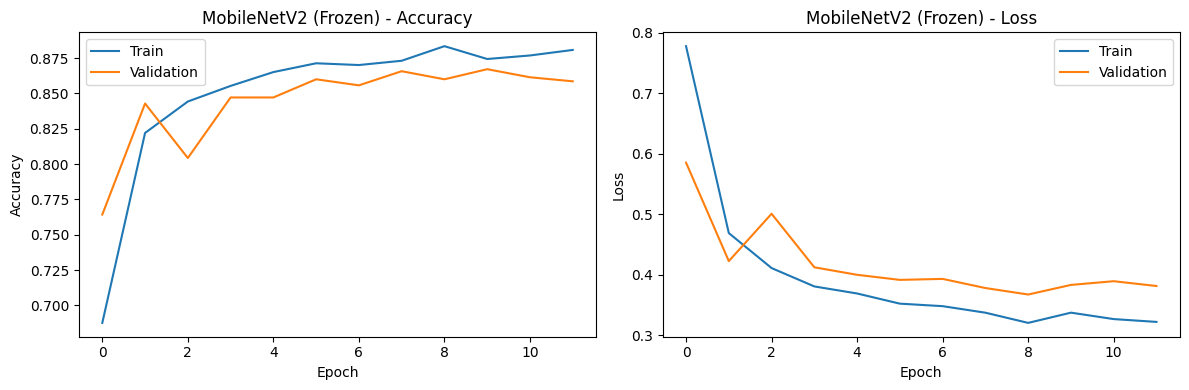

In [ ]:
# 8A: Plotting Training Curves (Accuracy + Loss)


import matplotlib.pyplot as plt  # Plotting libraries for graphs

def plot_history(history, title="Training Curves"):                       # Function to plot training performance
    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"])                                 # Plots training accuracy values
    plt.plot(history.history["val_accuracy"])                             # Plots validation accuracy values
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])                                   # to distinguish curves

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"])                                     # Plots training loss values
    plt.plot(history.history["val_loss"])                                 # Plots validation loss values
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Validation"])

    plt.tight_layout()
    plt.show()

# Calling the function using your training output history
plot_history(history, "MobileNetV2 (Frozen)")


## **8b. Final Test Evaluation (Accuracy + Loss)**

Runs model.evaluate(test_ds):

- Reports test accuracy and test loss

**Purpose**: Gives the final generalization performance on unseen data.

In [ ]:
# 8B: Evaluating Model on Test Dataset

test_loss, test_acc = model.evaluate(test_ds, verbose=1)                  # Evaluating models on test set

print("\n - Final Test Evaluation Results")
print(f"Test Accuracy: {test_acc:.4f}")                                   # Printing test accuracy to 4 decimal places
print(f"Test Loss:     {test_loss:.4f}")                                  # Printing test loss to 4 decimal places


22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8422 - loss: 0.4001

 - Final Test Evaluation Results
Test Accuracy: 0.8494
Test Loss:     0.4027


## **8c. Confusion Matrix + Classification Report**

Generates:

- Confusion matrix (class-by-class errors)

- Precision, Recall, F1-score per class

**Purpose**: Shows where the model is strong/weak


 Classification Report
              precision    recall  f1-score   support

      glioma       0.88      0.82      0.85       143
     healthy       0.94      0.91      0.92       230
  meningioma       0.82      0.65      0.73       165
   pituitary       0.76      0.99      0.86       166

    accuracy                           0.85       704
   macro avg       0.85      0.84      0.84       704
weighted avg       0.86      0.85      0.85       704



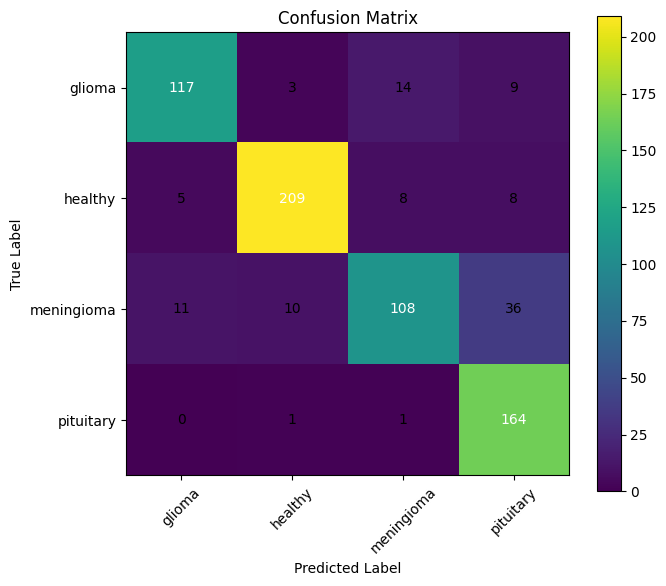

In [ ]:
# 8C: Confusion Matrix + Classification Report


import numpy as np                                                        # for numerical operations
from sklearn.metrics import confusion_matrix, classification_report       # evaluation metrics

y_true = []                                                              # to store true labels
y_pred = []                                                              # to store predicted labels

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)                             # Getting probability predictions (softmax outputs)
    preds = np.argmax(probs, axis=1)                                     # Convert probabilities into class index predictions
    y_true.extend(labels.numpy())                                        # Save ground truth labels
    y_pred.extend(preds)                                                 # Save predicted labels

y_true = np.array(y_true)                                                # Convert to numpy array
y_pred = np.array(y_pred)

print("\n Classification Report")                                         # report header
print(classification_report(y_true, y_pred, target_names=class_names))    # Precision, recall, F1-score per class

cm = confusion_matrix(y_true, y_pred)                                    # Creating a confusion matrix

plt.figure(figsize=(7, 6))                                               # Creating a figure window
plt.imshow(cm, interpolation="nearest")                                  # Displaying confusion matrix as an image
plt.title("Confusion Matrix")
plt.colorbar()

ticks = np.arange(len(class_names))                                      # Tick positions based on number of classes
plt.xticks(ticks, class_names, rotation=45)                              # X-axis class labels
plt.yticks(ticks, class_names)                                           # Y-axis class labels

thresh = cm.max() / 2
for i in range(cm.shape[0]):                                             # Loop through rows
    for j in range(cm.shape[1]):                                         # Loop through columns
        plt.text(                                                        # Putting value in each cell
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## **9A. Model Saving**

The trained model is saved in .keras format for reuse, evaluation, or deployment.
Saving the best-performing model ensures reproducibility and allows inference without retraining.

In [ ]:
# 9A: Save Model

MODEL_SAVE_PATH = "brain_tumor_mobilenetv2_best.keras"  # File name for saving the best trained model

model.save(MODEL_SAVE_PATH)

print(f"- Model saved successfully as: {MODEL_SAVE_PATH}")  # Confirmation msg


- Model saved successfully as: brain_tumor_mobilenetv2_best.keras


## **9B. Sample Predictions with Confidence Scores**

In this block a display of the grid of MRI images along with:

- Predicted class

- Prediction confidence (softmax probability)

- Ground-truth label

It visually demonstrates the model’s decision-making ability and confidence level on unseen test samples.

 Figure: Brain MRI Prediction (Model vs Ground Truth)


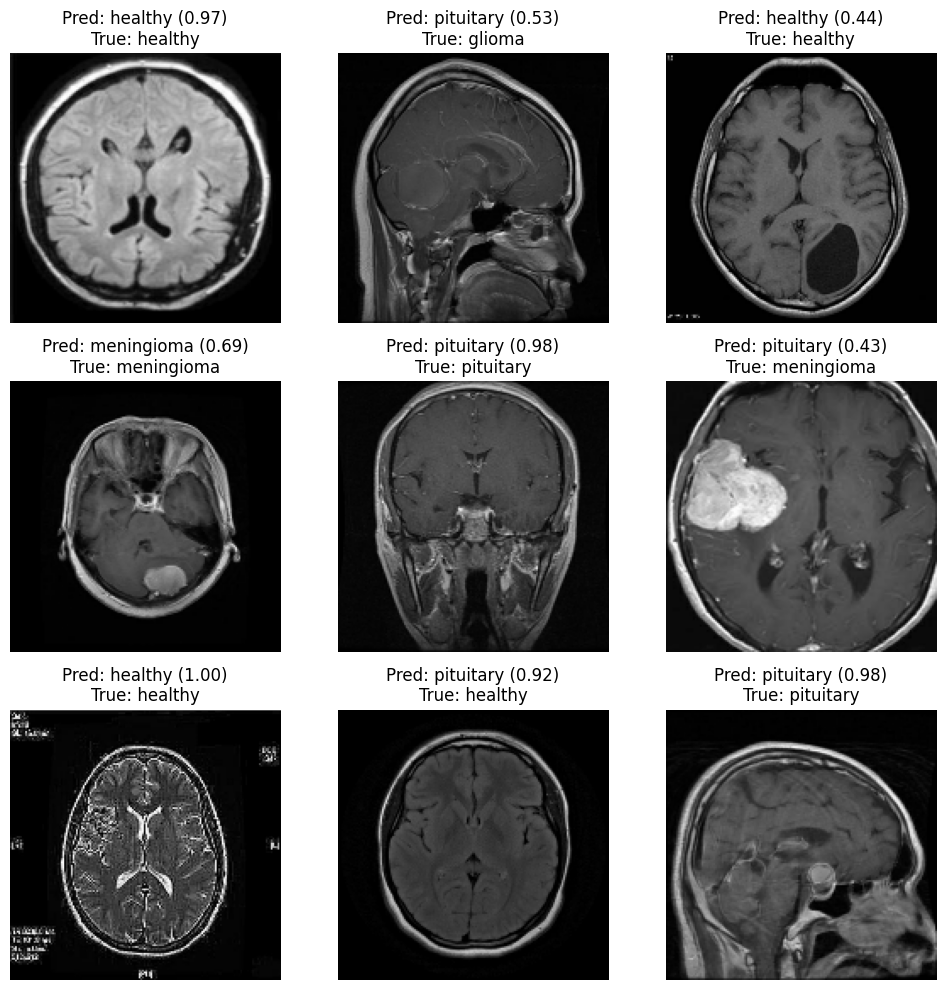

In [ ]:
# 9B: Showing Sample Predictions with Probabilities

import numpy as np
import matplotlib.pyplot as plt

NUM_SHOW = 9                                 # the number of example images to display
shown = 0                                    # Counter to stop after NUM_SHOW

print(" Figure: Brain MRI Prediction (Model vs Ground Truth)")

plt.figure(figsize=(10, 10))                 # square canvas

for images, labels in test_ds:
    probs = model.predict(images, verbose=0) # Predict probabilities for each image
    preds = np.argmax(probs, axis=1)         # Convert probabilities to predicted class index

    for i in range(len(images)):
        true_label = int(labels[i].numpy())  # Converting true label to Python int
        pred_label = int(preds[i])           # Converting predicted label to Python int
        confidence = float(np.max(probs[i])) # the highest predicted probability is the confidence score

        ax = plt.subplot(3, 3, shown + 1)                  # subplot cell
        plt.imshow(images[i].numpy().astype("uint8"))      # Displaying MRI image
        plt.axis("off")                                    # Hiding axis

        # Title contains: Predicted + Confidence + True
        title = f"Pred: {class_names[pred_label]} ({confidence:.2f})\nTrue: {class_names[true_label]}"
        plt.title(title)

        shown += 1
        if shown >= NUM_SHOW:                # Stop when shown enough images
            break

    if shown >= NUM_SHOW:                    # Breaking the outer loop too
        break

plt.tight_layout()
plt.show()

## **9C. Misclassification Analysis (Top Errors)**

This block identifies and visualizes incorrectly classified MRI scans.

It helps analyze where the model fails, highlighting confusing tumor patterns or ambiguous images that contribute to classification errors.

 Figure: Misclassification Review (Incorrect Predictions)


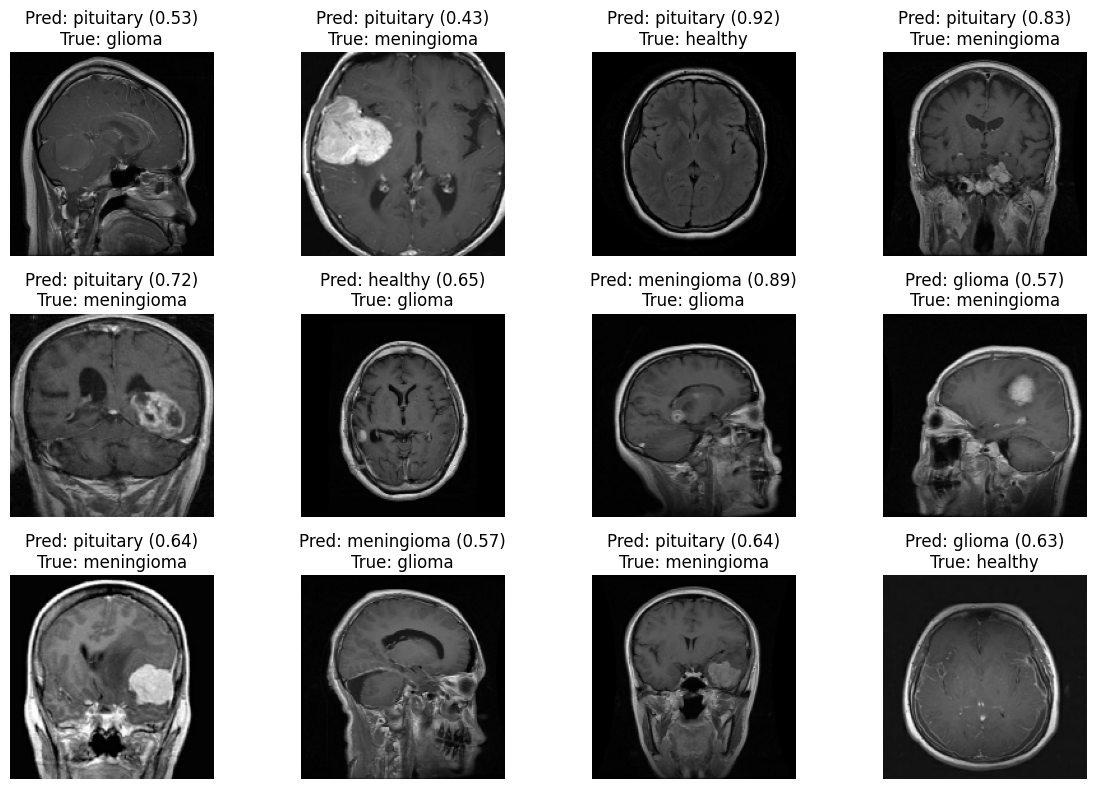

- Total misclassifications shown: 12


In [ ]:
# 9C: Misclassification Analysis (Top mistakes)

import numpy as np
import matplotlib.pyplot as plt

MAX_MISTAKES_TO_SHOW = 12                    # Show up to 12 wrong examples
mistakes_found = 0                           # Counter for mistakes

print(" Figure: Misclassification Review (Incorrect Predictions)")  # Professional figure label

plt.figure(figsize=(12, 8))                  # a larger canvas for multiple examples

for images, labels in test_ds:
    probs = model.predict(images, verbose=0) # Predicingt class probabilities
    preds = np.argmax(probs, axis=1)         # Converting probabilities to predicted class

    for i in range(len(images)):             # Loop through batch
        true_label = int(labels[i].numpy())  # True class index
        pred_label = int(preds[i])           # Predicted class index

        if pred_label != true_label:
            confidence = float(np.max(probs[i]))  # Predicted confidence

            ax = plt.subplot(3, 4, mistakes_found + 1)
            plt.imshow(images[i].numpy().astype("uint8"))  # Showing the MRI image
            plt.axis("off")                                # Hide axes


            title = f"Pred: {class_names[pred_label]} ({confidence:.2f})\nTrue: {class_names[true_label]}"
            plt.title(title)

            mistakes_found += 1                         # Increase mistake count
            if mistakes_found >= MAX_MISTAKES_TO_SHOW:  # Stop if reached max
                break

    if mistakes_found >= MAX_MISTAKES_TO_SHOW:   # Stop outer loop
        break

plt.tight_layout()
plt.show()

print(f"- Total misclassifications shown: {mistakes_found}")

## **9D. Collecting Misclassified Samples**

All incorrect predictions are stored along with:

- The input image

- True label

- Predicted label

- Model confidence

This enables deeper offline analysis and supports error analysis reporting.

In [ ]:
# 9D: Collect Misclassified Samples (Wrong Predictions Only)

import numpy as np

wrong_images = []   # Stores the images that were predicted incorrectly
wrong_true = []     # Stores the true labels (ground truth)
wrong_pred = []     # Stores the predicted labels
wrong_conf = []     # Stores the model confidence for predicted label

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)                            # Extract the confidence (max probability) per each image

    for i in range(len(images)):
        if int(preds[i]) != int(labels[i]):
            wrong_images.append(images[i])
            wrong_true.append(int(labels[i]))
            wrong_pred.append(int(preds[i]))
            wrong_conf.append(float(confs[i]))

print(f"- Total misclassified samples found: {len(wrong_images)}")

- Total misclassified samples found: 106


## **9D-2. Visualization of Misclassified Samples**

A subset of misclassified MRI scans is plotted with prediction confidence.

This provides insight into whether incorrect predictions occur with high or low confidence, which is critical for evaluating model reliability in medical imaging tasks.

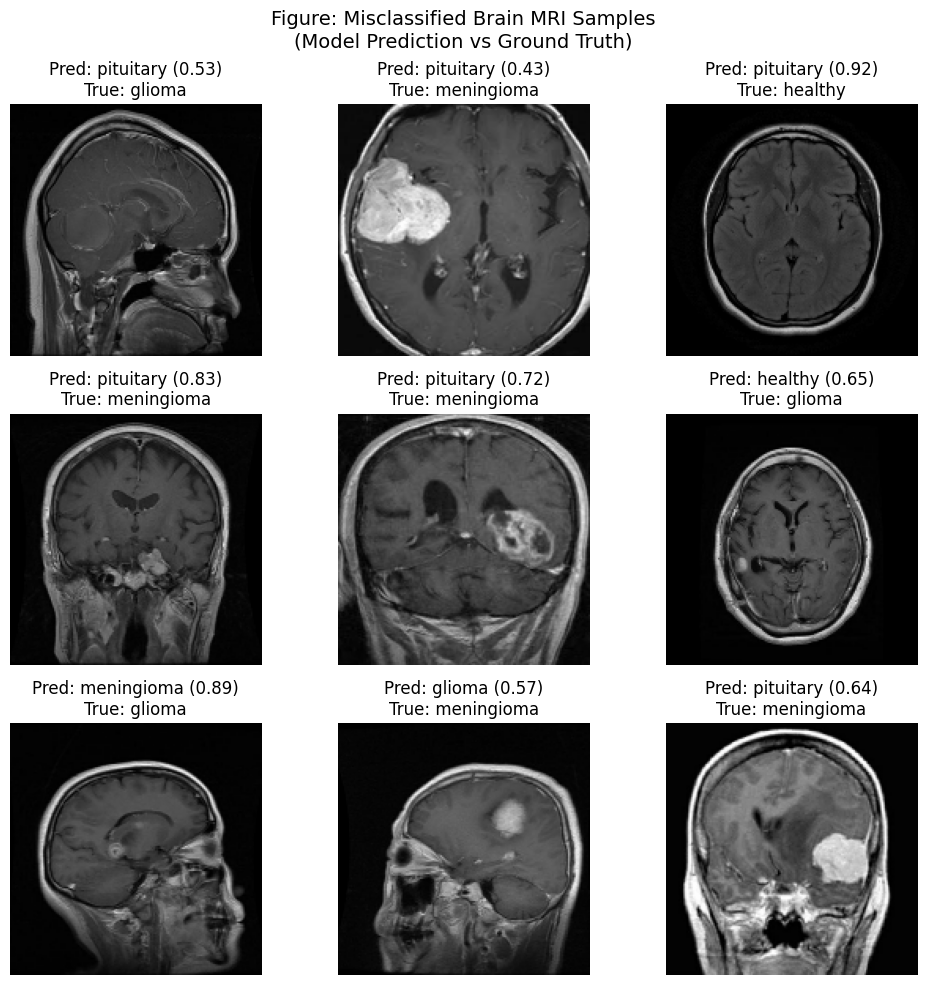

In [ ]:
# 9D-2: Plot Misclassified Samples (With Confidence)

import matplotlib.pyplot as plt

NUM_SHOW = 9  # Number of misclassified examples to display

if len(wrong_images) == 0:
    print("- No misclassifications found in this test subset.")
else:
    plt.figure(figsize=(10, 10))

    for i in range(min(NUM_SHOW, len(wrong_images))):  # Loop up to NUM_SHOW mistakes
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(wrong_images[i].numpy().astype("uint8"))
        plt.axis("off")

        # Title: predicted vs true + model confidence
        title = (
            f"Pred: {class_names[wrong_pred[i]]} ({wrong_conf[i]:.2f})\n"
            f"True: {class_names[wrong_true[i]]}"
        )
        plt.title(title)

    plt.suptitle(
        "Figure: Misclassified Brain MRI Samples\n(Model Prediction vs Ground Truth)",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


## **9E: Low-Confidence Predictions (Model Uncertainty)**

Finding predictions where the model is not confident (confidence < CONF_THRESHOLD, e.g. 0.55).

This helps demonstrate uncertainty handling (the cases the model is unsure about)

In [ ]:
# 9E: Low-Confidence Predictions (Model Uncertainty)

low_conf_images = []   # Stores low-confidence images
low_conf_true = []
low_conf_pred = []
low_conf_score = []

CONF_THRESHOLD = 0.55  # Anything below this here is considered uncertain

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)                            # Confidence per image

    for i in range(len(images)):
        if float(confs[i]) < CONF_THRESHOLD:                 # If confidence is low
            low_conf_images.append(images[i])
            low_conf_true.append(int(labels[i]))
            low_conf_pred.append(int(preds[i]))
            low_conf_score.append(float(confs[i]))

print(f"- Low-confidence samples found (< {CONF_THRESHOLD}): {len(low_conf_images)}")

- Low-confidence samples found (< 0.55): 55


## **9E-2: Plot Low-Confidence Samples**

Plotting the low-confidence images found, with predicted label, confidence, and true label—basically your uncertainty visualization.

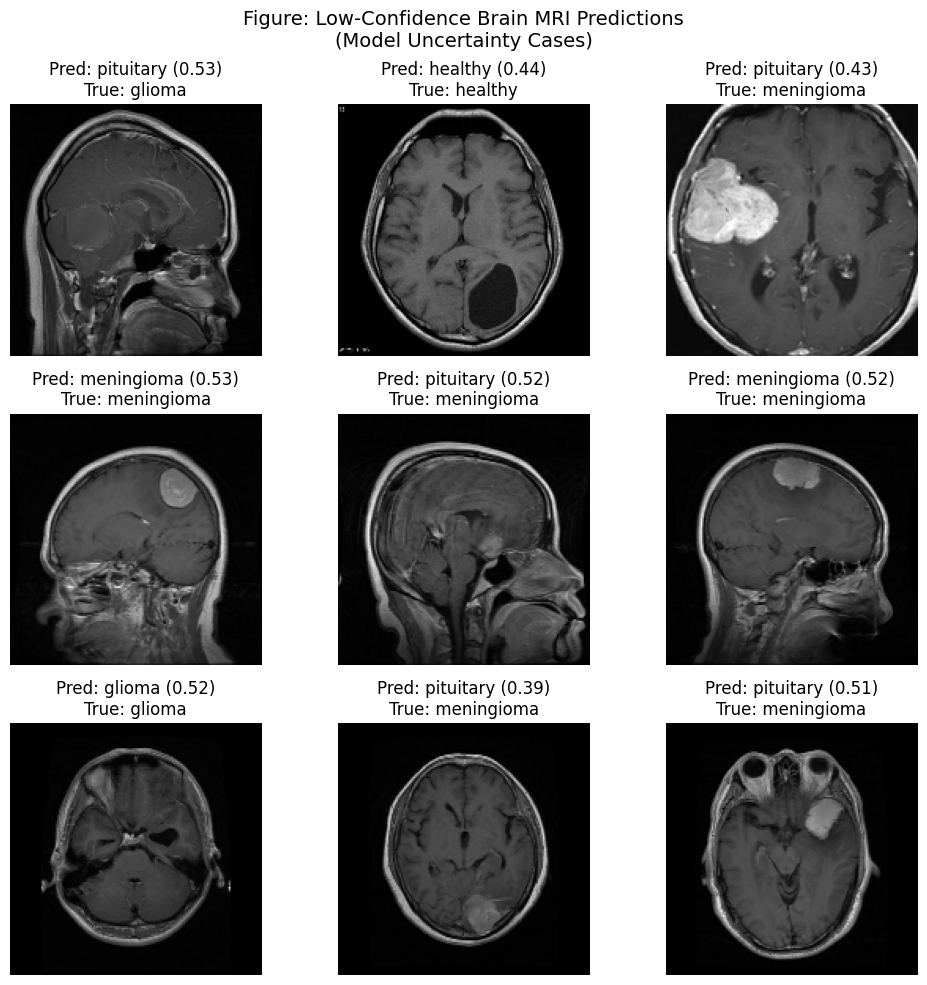

In [ ]:
# 9E-2: Plot Low-Confidence Samples

NUM_SHOW = 9  # Number to display

if len(low_conf_images) == 0:
    print("- No low-confidence samples found in this test subset.")
else:
    plt.figure(figsize=(10, 10))

    for i in range(min(NUM_SHOW, len(low_conf_images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(low_conf_images[i].numpy().astype("uint8"))
        plt.axis("off")

        title = (
            f"Pred: {class_names[low_conf_pred[i]]} ({low_conf_score[i]:.2f})\n"
            f"True: {class_names[low_conf_true[i]]}"
        )
        plt.title(title)

    plt.suptitle(
        "Figure: Low-Confidence Brain MRI Predictions\n(Model Uncertainty Cases)",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()
